In [4]:
import h5py
import numpy as np

# Point this to the newly generated chain file in your MCMC_Chains folder
chain_path = "MCMC_Chains/Test_run/f1CDM_v/CC/CC_zeus.h5" 

with h5py.File(chain_path, "r") as f:
    print(f"--- Checking {chain_path} ---")
    print(f"Datasets found: {list(f.keys())}")
    
    if "log_like" in f:
        log_like = np.array(f["log_like"])
        log_prob = np.array(f["log_prob"])
        samples = np.array(f["samples"]) # or however your chain is named
        
        print(f"\nShapes:")
        print(f"Samples:   {samples.shape}")
        print(f"log_prob:  {log_prob.shape}")
        print(f"log_like:  {log_like.shape}")
        
        print(f"\nFirst 3 log_like values: {log_like[:3]}")
    else:
        print("\n❌ 'log_like' dataset missing!")

--- Checking MCMC_Chains/Test_run/f1CDM_v/CC/CC_zeus.h5 ---
Datasets found: ['log_prob', 'samples']

❌ 'log_like' dataset missing!


In [8]:
#Emcee test
import h5py
import numpy as np
import os
import glob

# Find the most recently modified .h5 file that does NOT have 'zeus' in the name
h5_files = [f for f in glob.glob("MCMC_Chains/**/*.h5", recursive=True) if "zeus" not in f.lower()]

if not h5_files:
    print("❌ No emcee .h5 files found. Run a model using emcee first!")
else:
    latest_emcee = max(h5_files, key=os.path.getmtime)
    print(f"✅ Found latest emcee chain: {latest_emcee}")
    
    with h5py.File(latest_emcee, "r") as f:
        if "log_like" not in f or "log_prob" not in f:
            print("❌ Chain is missing either log_prob or log_like.")
        else:
            log_prob = np.array(f["log_prob"])
            log_like = np.array(f["log_like"])
            
            print(f"Shape of log_prob: {log_prob.shape}")
            print(f"Shape of log_like: {log_like.shape}")
            
            # Check the maximum absolute difference between the two arrays
            diff = np.abs(log_prob - log_like)
            max_diff = np.max(diff)
            
            print(f"\n--- RESULTS ---")
            print(f"Maximum difference between log_prob and log_like: {max_diff}")
            
            if max_diff == 0.0:
                print("🎉 Claude is 100% correct! log_prob == log_like exactly in your codebase.")
                print("We can safely use his 1-line fix for Zeus.")
            else:
                print("⚠️ WARNING: There is a difference! Your priors are NOT exactly zero.")
                print(f"First 5 log_prob: {log_prob[:5]}")
                print(f"First 5 log_like: {log_like[:5]}")
                print("We CANNOT use the shortcut and must calculate true likelihoods separately.")

✅ Found latest emcee chain: MCMC_Chains/Test_run/f1CDM_v/BBN_PryMordial_DESI_DR2/BBN_PryMordial+DESI_DR2.h5
Shape of log_prob: (19200,)
Shape of log_like: (19200,)

--- RESULTS ---
Maximum difference between log_prob and log_like: 0.0
🎉 Claude is 100% correct! log_prob == log_like exactly in your codebase.
We can safely use his 1-line fix for Zeus.


In [6]:
import h5py
with h5py.File("MCMC_Chains/Test_run/f1CDM_v/CC/CC_zeus.h5", "r") as f:
    print(list(f.keys()))

['log_prob', 'samples']


In [ ]:
#!/usr/bin/env python3
"""
Read-only diagnostic script for the classy / clik import problems.

This script does NOT install, uninstall, modify, delete, or write to
anything on your system. It only inspects the current environment and
prints what it finds. Safe to run as many times as you like.

Usage:
    python kosmulator_diagnose.py
"""

import sys
import os
import glob
import importlib.util

def section(title):
    print("\n" + "=" * 70)
    print(title)
    print("=" * 70)


def try_import(modname):
    try:
        mod = __import__(modname)
        path = getattr(mod, "__file__", "(no __file__ — built-in or namespace pkg)")
        return True, path
    except Exception as e:
        return False, f"{type(e).__name__}: {e}"


section("1) Python interpreter being used right now")
print("sys.executable:", sys.executable)
print("sys.version:", sys.version)

section("2) PYTHONPATH environment variable (as seen by THIS interpreter)")
pp = os.environ.get("PYTHONPATH", "")
if pp:
    for i, p in enumerate(pp.split(os.pathsep)):
        print(f"  [{i}] {p}")
else:
    print("  (not set)")

section("3) Full sys.path (what Python actually searches, in order)")
for i, p in enumerate(sys.path):
    print(f"  [{i}] {p}")

section("4) Attempting import of 'classy'")
ok, info = try_import("classy")
print("SUCCESS" if ok else "FAILED", "->", info)

section("5) Attempting import of 'clik'")
ok, info = try_import("clik")
print("SUCCESS" if ok else "FAILED", "->", info)

section("6) Searching for compiled classy .so files under $HOME (read-only glob, no /)")
home = os.path.expanduser("~")
hits = glob.glob(os.path.join(home, "**", "_classy*.so"), recursive=True)
if hits:
    for h in hits:
        print(" ", h)
else:
    print("  (none found under", home, ")")

section("7) Searching for clik package under $HOME (read-only glob, no /)")
hits = glob.glob(os.path.join(home, "**", "site-packages", "clik", "__init__.py"), recursive=True)
if hits:
    for h in hits:
        print(" ", h)
else:
    print("  (none found under", home, ")")

section("8) Searching for Kosmulator's own CLASS cache directory")
cache_dir = os.path.join(home, "Kosmulator", "Class")
if os.path.isdir(cache_dir):
    print("  Found:", cache_dir)
    for entry in sorted(os.listdir(cache_dir)):
        full = os.path.join(cache_dir, entry)
        print("   -", entry, "(dir)" if os.path.isdir(full) else "(file)")
else:
    print("  Not found at:", cache_dir)

section("9) Conda / environment info")
print("CONDA_DEFAULT_ENV:", os.environ.get("CONDA_DEFAULT_ENV", "(not set)"))
print("CONDA_PREFIX:", os.environ.get("CONDA_PREFIX", "(not set)"))

section("DONE")
print("Copy everything above (from '1)' to here) and send it back.")
print("This script changed nothing on your system.")


1) Python interpreter being used right now
sys.executable: /usr/bin/python3
sys.version: 3.12.3 (main, Jun 19 2026, 12:46:00) [GCC 13.3.0]

2) PYTHONPATH environment variable (as seen by THIS interpreter)
  [0] /home/user/Kosmulator_Planck/code/plc_3.0/plc-3.1/lib/python/site-packages
  [1] 
  [2] /home/user/Kosmulator_Planck/code/plc_3.0/plc-3.1/lib/python/site-packages
  [3] 

3) Full sys.path (what Python actually searches, in order)
  [0] 
  [1] /home/user/Kosmulator_Planck/code/plc_3.0/plc-3.1/lib/python/site-packages
  [2] /home/user/Kosmulator
  [3] /usr/lib/python312.zip
  [4] /usr/lib/python3.12
  [5] /usr/lib/python3.12/lib-dynload
  [6] /home/user/.local/lib/python3.12/site-packages
  [7] /usr/local/lib/python3.12/dist-packages
  [8] /usr/lib/python3/dist-packages

4) Attempting import of 'classy'
FAILED -> ModuleNotFoundError: No module named 'classy'

5) Attempting import of 'clik'
Cannot use clik wrapper (cause = 'No module named 'clik.lkl'')
Cannot use clik_lensing wrap

In [3]:


import numpy as np

cov_path = "Observations/DESY5_covsys_000.txt"

# 1. Load and reshape
raw_data = np.loadtxt(cov_path)
n_dim = int(raw_data[0])
cov_loaded = raw_data[1:].reshape((n_dim, n_dim))
cov_loaded = 0.5 * (cov_loaded + cov_loaded.T)

# 2. Check shape and inversion sanity
print(f"Shape: {cov_loaded.shape}")
print(f"First 5 diagonal elements: {np.diag(cov_loaded)[:5]}")

# 3. Test inversion (mocking statistical error if data_sne isn't loaded yet)
mock_stat = np.ones(n_dim) * 0.1
cov_total = cov_loaded + np.diag(mock_stat**2)
inv_cov = np.linalg.inv(cov_total)

print("Inversion successful! Matrix is non-singular.")

Shape: (1829, 1829)
First 5 diagonal elements: [0.00019319 0.00853043 0.0027202  0.00053827 0.00153153]
Inversion successful! Matrix is non-singular.


In [2]:
from Kosmulator_main import Config
import User_defined_modules as UDM
from Kosmulator_main import constants as K

models = UDM.Get_model_names(["LCDM_v"])

prior_limits = {
    "Omega_m": (0.01, 1.0),
    "H_0": (40.0, 100.0),
    "r_d": (0.01, 1000.0),
    "M_abs": (-30.0, -5.0),
    # ... include whatever else your true DESY5/DESI setup needs;
    # copying the full dict from Kosmulator.py is safest
}

true_values = {
    "Omega_m": 0.315,
    "H_0": 67.4,
    "r_d": K.R_D_SINGLETON,
    "M_abs": -19.2,
}

CONFIG, data = Config.create_config(
    models=models,
    true_values=true_values,
    prior_limits=prior_limits,
    restrictions=UDM.Get_model_restrictions(["LCDM_v"]),
    observation=[["DESI_DR2", "DESY5"]],
    nwalkers=8,
    nsteps=100,
    burn=10,
    model_name=["LCDM_v"],
    logger=None,
)

print(list(data.keys()))  # confirm DESI_DR2 / DESY5 are in there

WARNING | Added ['H_0', 'r_d'] to parameters for ['DESI_DR2', 'DESY5'] in model LCDM_v


['CMB_lensing_RAW', 'CMB_lensing_CMBMARGED', 'DESI_DR2', 'DESY5']


In [5]:
import inspect
from Kosmulator_main import Statistical_packages as SP
print(inspect.getsource(SP.Calc_DESI_chi))

def Calc_DESI_chi(data, Model_func, param_dict, Type) -> float:
    """
    χ² for DESI VI-style BAO vectors with mixed observables.

    Supported type codes (after normalisation):
      3: D_V / r_d
      5: D_A / r_d
      6: D_H / r_d
      7: r_d / D_V
      8: D_M / r_d

    Any type==4 entries (raw D_V in Mpc) are auto-normalised to D_V / r_d
    and relabelled to 3, using a heuristic on the observed values.
    """
    def _must_calibrate(Type: str) -> bool:
        T = (Type or "").upper()
        return ("BBN" in T) or ("THETA" in T) or ("CMB" in T)

    z = np.asarray(data["redshift"], dtype=float)
    meas = np.asarray(data["measurement"], dtype=float).copy()
    types = np.asarray(data["type"], dtype=int).copy()
    cov = data.get("cov", None)
    inv_c = data.get("inv_cov", None)
    
    param_dict = _ensure_background_params(param_dict)

    DM = UDM.Comoving_distance_vectorized(Model_func, z, param_dict)  # Mpc
    Ez = Model_func(z, param_dict)
    DA = DM / (1.0 + z)

In [8]:
param_dict = {"Omega_m": 0.01, "H_0": 40.0, "r_d": 422.76}
chi2 = Calc_DESI_chi(data["DESI_DR2"], MODEL_func, param_dict, "DESI_DR2")
print("Wall-hugging point:", chi2)

sane_dict = {"Omega_m": 0.315, "H_0": 67.4, "r_d": 147.5}
chi2_sane = Calc_DESI_chi(data["DESI_DR2"], MODEL_func, sane_dict, "DESI_DR2")
print("Sane point:", chi2_sane)
sane_dict_desy5 = {"Omega_m": 0.315, "H_0": 67.4, "M_abs": -19.35}
# model_val needs computing first — Calc_Generic_SNe_chi takes a distance-modulus array, not param_dict alone

Wall-hugging point: 10531.308014428996
Sane point: 23.0879647474472


In [9]:
from Kosmulator_main.Statistical_packages import Calc_Generic_SNe_chi
import Kosmulator_main.utils as U

redshift = data["DESY5"]["redshift"]
comoving_distances = U.Comoving_distance_vectorized(MODEL_func, redshift, sane_dict_desy5)
model_val = 25 + 5 * np.log10(comoving_distances * (1 + redshift))

chi2_desy5 = Calc_Generic_SNe_chi(obs_data=data["DESY5"], model=model_val, param_dict=sane_dict_desy5)
print("DESY5 sane point:", chi2_desy5)

DESY5 sane point: 22005656.0717076


In [10]:
print("inv_cov" in data["DESY5"])
print("cov" in data["DESY5"])
if "inv_cov" in data["DESY5"]:
    ic = np.asarray(data["DESY5"]["inv_cov"])
    print("shape:", ic.shape)
    print("diagonal sample:", np.diag(ic)[:5])

True
True
shape: (1829, 1829)
diagonal sample: [106.16407949  53.77230367  18.32152107  44.20288861  38.06980482]


In [12]:
cov = np.asarray(data["DESY5"]["cov"])
inv_cov = np.asarray(data["DESY5"]["inv_cov"])

product = cov @ inv_cov
identity_check = np.allclose(product, np.eye(product.shape[0]), atol=1e-3)
print("cov @ inv_cov ≈ I ?", identity_check)
print("diagonal of product (should be ~1):", np.diag(product)[:5])
print("off-diagonal sample (should be ~0):", product[0, 1:5])

residual_test = np.zeros(cov.shape[0])  # dummy, just testing the matrix itself
manual_inv = np.linalg.inv(cov)
print("manual inverse diagonal sample:", np.diag(manual_inv)[:5])
print("stored inv_cov diagonal sample:", np.diag(inv_cov)[:5])

cov @ inv_cov ≈ I ? True
diagonal of product (should be ~1): [1. 1. 1. 1. 1.]
off-diagonal sample (should be ~0): [ 2.49366500e-18 -2.71050543e-19 -1.08420217e-19  1.68051337e-18]
manual inverse diagonal sample: [106.16407949  53.77230367  18.32152107  44.20288861  38.06980482]
stored inv_cov diagonal sample: [106.16407949  53.77230367  18.32152107  44.20288861  38.06980482]


In [14]:
type_data = np.asarray(data["DESY5"]["type_data"])
M = sane_dict_desy5.get("M_abs", -19.35)
residual = (type_data - M) - model_val

print("type_data range:", type_data.min(), type_data.max())
print("model_val range:", model_val.min(), model_val.max())
print("residual range:", residual.min(), residual.max())
print("residual mean/std:", residual.mean(), residual.std())

print("data_is_distance_modulus flag:", data["DESY5"].get("data_is_distance_modulus"))

type_data range: 34.9553 44.5882
model_val range: 35.19286803192841 44.46948065886076
residual range: 18.334227772577783 22.313040866068057
residual mean/std: 19.31293612315145 0.2603881184324923
data_is_distance_modulus flag: False


In [15]:
residual_correct = type_data - model_val
print("corrected residual mean/std:", residual_correct.mean(), residual_correct.std())

corrected residual mean/std: -0.03706387684855396 0.2603881184324923


In [16]:
inv_cov = data["DESY5"]["inv_cov"]
chi2_fixed = float(residual_correct @ inv_cov @ residual_correct)
print("DESY5 sane point, corrected:", chi2_fixed)

DESY5 sane point, corrected: 2046.6754379201648


In [1]:
import classy, clik
print("classy:", classy.__file__)
print("clik:", clik.__file__)

classy: /home/conda/miniconda3/envs/pykosm/lib/python3.11/site-packages/classy.cpython-311-x86_64-linux-gnu.so
clik: /home/user/Kosmulator_Planck/code/plc_3.0/plc-3.1/lib/python/site-packages/clik/__init__.py


[RWMH] Acceptance: 75.4% | Total Steps: 2500
[HMC ] Acceptance: 99.8% | Total Steps: 2500

--- Diagnostic Metrics ---
RWMH decorrelation lag (steps to drop below 0.1 autocorr): >120
HMC  decorrelation lag (steps to drop below 0.1 autocorr): 1


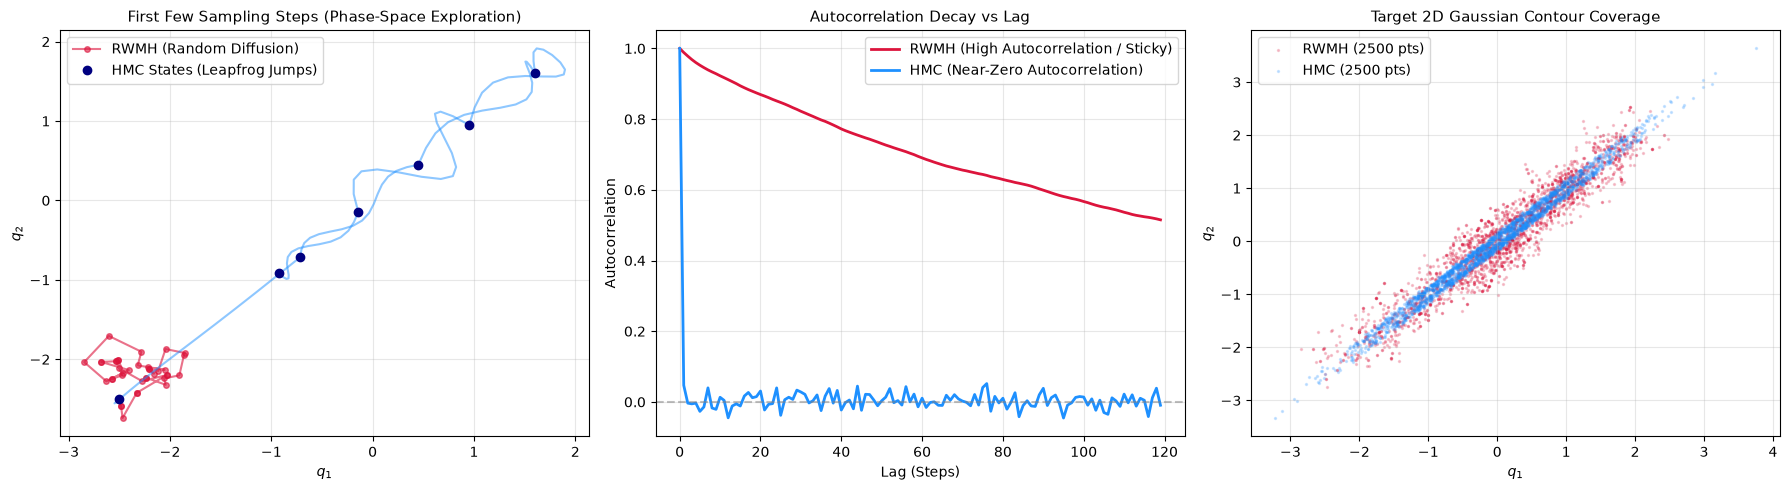

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# --------------------------------------------------
# 1. Target: Heavily Correlated 2D Gaussian
# --------------------------------------------------
# True Covariance with strong correlation (rho = 0.95)
cov_true = np.array([[1.0, 0.95], 
                     [0.95, 1.0]])
inv_cov = np.linalg.inv(cov_true)

def U(q):
    """Potential energy: -ln P(q)"""
    return 0.5 * float(q.T @ inv_cov @ q)

def grad_U(q):
    """Force vector: dU/dq"""
    return inv_cov @ q

# --------------------------------------------------
# 2. Sampler 1: Standard Random Walk (Metropolis)
# --------------------------------------------------
def run_random_walk(n_samples=2000, step_scale=0.15, q_init=np.array([0.0, 0.0])):
    q_current = q_init.copy()
    samples = [q_current.copy()]
    accepted = 0

    for _ in range(n_samples - 1):
        # Blind random Gaussian jump
        proposal = q_current + np.random.normal(scale=step_scale, size=2)
        log_prob_diff = -(U(proposal) - U(q_current))

        if np.log(np.random.uniform()) < log_prob_diff:
            q_current = proposal
            accepted += 1
        samples.append(q_current.copy())

    print(f"[RWMH] Acceptance: {accepted / n_samples * 100:.1f}% | Total Steps: {n_samples}")
    return np.array(samples)

# --------------------------------------------------
# 3. Sampler 2: Hamiltonian Monte Carlo (Leapfrog)
# --------------------------------------------------
def leapfrog(q, p, eps, L):
    q, p = q.copy(), p.copy()
    p -= 0.5 * eps * grad_U(q)
    trajectory = [q.copy()]
    for i in range(L):
        q += eps * p
        if i != L - 1:
            p -= eps * grad_U(q)
        trajectory.append(q.copy())
    p -= 0.5 * eps * grad_U(q)
    return q, -p, np.array(trajectory)

def run_hmc(n_samples=2000, eps=0.12, L=18, q_init=np.array([0.0, 0.0])):
    q_current = q_init.copy()
    samples = [q_current.copy()]
    trajectories = []
    accepted = 0

    for _ in range(n_samples - 1):
        p_current = np.random.normal(size=2)
        H_start = U(q_current) + 0.5 * np.dot(p_current, p_current)

        q_prop, p_prop, path = leapfrog(q_current, p_current, eps, L)
        H_end = U(q_prop) + 0.5 * np.dot(p_prop, p_prop)

        # Detailed balance acceptance
        if np.log(np.random.uniform()) < (H_start - H_end):
            q_current = q_prop
            accepted += 1
            trajectories.append(path)
        else:
            trajectories.append(path)
            
        samples.append(q_current.copy())

    print(f"[HMC ] Acceptance: {accepted / n_samples * 100:.1f}% | Total Steps: {n_samples}")
    return np.array(samples), trajectories

# --------------------------------------------------
# 4. Helper: Autocorrelation Function
# --------------------------------------------------
def compute_autocorr(chain_1d, max_lag=100):
    chain_centered = chain_1d - np.mean(chain_1d)
    var = np.var(chain_1d)
    n = len(chain_1d)
    autocorr = [1.0]
    for lag in range(1, max_lag):
        c = np.sum(chain_centered[:n - lag] * chain_centered[lag:]) / (n - lag)
        autocorr.append(c / var)
    return np.array(autocorr)

# --------------------------------------------------
# 5. Execution & Plotting Diagnostics
# --------------------------------------------------
n_steps = 2500
q_start = np.array([-2.5, -2.5])

samples_rw = run_random_walk(n_samples=n_steps, step_scale=0.18, q_init=q_start)
samples_hmc, paths_hmc = run_hmc(n_samples=n_steps, eps=0.13, L=16, q_init=q_start)

# Effective Sample Size metric: Steps needed for autocorrelation < 0.1
auto_rw = compute_autocorr(samples_rw[:, 0], max_lag=120)
auto_hmc = compute_autocorr(samples_hmc[:, 0], max_lag=120)

tau_rw = np.where(auto_rw < 0.1)[0]
tau_hmc = np.where(auto_hmc < 0.1)[0]
lag_rw = tau_rw[0] if len(tau_rw) > 0 else ">120"
lag_hmc = tau_hmc[0] if len(tau_hmc) > 0 else ">120"

print(f"\n--- Diagnostic Metrics ---")
print(f"RWMH decorrelation lag (steps to drop below 0.1 autocorr): {lag_rw}")
print(f"HMC  decorrelation lag (steps to drop below 0.1 autocorr): {lag_hmc}")

# Setup comparison figure
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Panel 1: Step Trajectories (First 40 steps)
ax = axes[0]
ax.plot(samples_rw[:40, 0], samples_rw[:40, 1], 'o-', color='crimson', 
        alpha=0.6, label='RWMH (Random Diffusion)', lw=1.5, markersize=4)

# Plot actual Hamiltonian leapfrog trajectories
for p in paths_hmc[:6]:
    ax.plot(p[:, 0], p[:, 1], color='dodgerblue', alpha=0.5, lw=1.5)
ax.plot(samples_hmc[:7, 0], samples_hmc[:7, 1], 'o', color='navy', 
        label='HMC States (Leapfrog Jumps)', markersize=6)

ax.set_title("First Few Sampling Steps (Phase-Space Exploration)", fontsize=11)
ax.set_xlabel(r"$q_1$")
ax.set_ylabel(r"$q_2$")
ax.legend(frameon=True)
ax.grid(True, alpha=0.3)

# Panel 2: Autocorrelation Function (The real efficiency metric)
ax = axes[1]
ax.plot(auto_rw, label='RWMH (High Autocorrelation / Sticky)', color='crimson', lw=2)
ax.plot(auto_hmc, label='HMC (Near-Zero Autocorrelation)', color='dodgerblue', lw=2)
ax.axhline(0, color='gray', linestyle='--', alpha=0.5)
ax.set_title("Autocorrelation Decay vs Lag", fontsize=11)
ax.set_xlabel("Lag (Steps)")
ax.set_ylabel("Autocorrelation")
ax.legend(frameon=True)
ax.grid(True, alpha=0.3)

# Panel 3: 2D Posterior Recovery
ax = axes[2]
ax.scatter(samples_rw[:, 0], samples_rw[:, 1], s=2, alpha=0.2, color='crimson', label=f'RWMH ({n_steps} pts)')
ax.scatter(samples_hmc[:, 0], samples_hmc[:, 1], s=2, alpha=0.2, color='dodgerblue', label=f'HMC ({n_steps} pts)')
ax.set_title("Target 2D Gaussian Contour Coverage", fontsize=11)
ax.set_xlabel(r"$q_1$")
ax.set_ylabel(r"$q_2$")
ax.legend(frameon=True)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("hmc_vs_rwmh_diagnostic.png", dpi=300)
plt.show()

In [6]:
import h5py

filepath = "MCMC_Chains/Test/wowaCDM_v/PantheonP/PantheonP.h5"

def print_structure(name, obj):
    if isinstance(obj, h5py.Dataset):
        print(f"Dataset: {name:30s} shape: {obj.shape}, dtype: {obj.dtype}")
    elif isinstance(obj, h5py.Group):
        print(f"Group:   {name}")

with h5py.File(filepath, "r") as f:
    f.visititems(print_structure)

Group:   mcmc
Dataset: mcmc/accepted                  shape: (12,), dtype: float64
Dataset: mcmc/blobs                     shape: (1000, 12), dtype: float64
Dataset: mcmc/chain                     shape: (1000, 12, 5), dtype: float64
Dataset: mcmc/log_prob                  shape: (1000, 12), dtype: float64


In [7]:
import h5py
import numpy as np

filepath = "MCMC_Chains/Test/wowaCDM_v/PantheonP/PantheonP.h5"

with h5py.File(filepath, "r") as f:
    chain = f["mcmc/chain"][:]          # shape: (1000, 12, 5)
    logprob = f["mcmc/log_prob"][:]     # shape: (1000, 12)

# Per-walker log-probability summary
for w in range(logprob.shape[1]):
    print(f"walker {w:2d}: min={logprob[:, w].min():.1f}  max={logprob[:, w].max():.1f}  final={logprob[-1, w]:.1f}")

walker  0: min=-76075.0  max=0.0  final=0.0
walker  1: min=-74151.9  max=0.0  final=0.0
walker  2: min=-705.8  max=0.0  final=0.0
walker  3: min=-1260.4  max=0.0  final=0.0
walker  4: min=-5749.1  max=0.0  final=0.0
walker  5: min=-4209.9  max=0.0  final=0.0
walker  6: min=-26425.1  max=0.0  final=0.0
walker  7: min=-830.9  max=0.0  final=0.0
walker  8: min=-146623.0  max=0.0  final=0.0
walker  9: min=-806.1  max=0.0  final=0.0
walker 10: min=-4589.0  max=0.0  final=0.0
walker 11: min=-12930.1  max=0.0  final=0.0


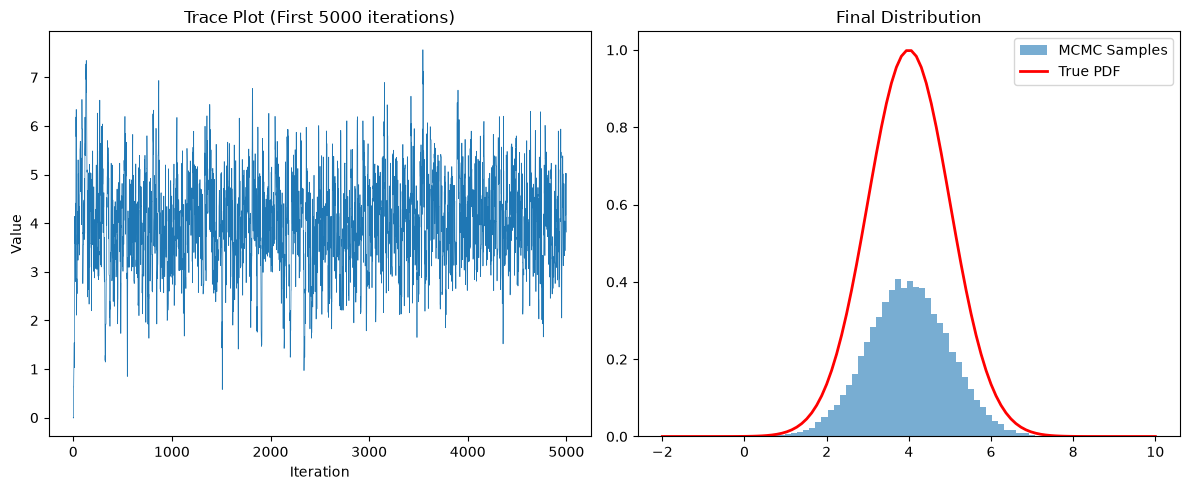

Acceptance Rate: 70.32%
Mean of samples: 3.99


In [1]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Define the Target Distribution (The distribution we want to sample from)
# In many real-world cases, we only know this up to a constant.
def target_pdf(x):
    # Normal distribution with mean=4 and std_dev=1
    return np.exp(-0.5 * ((x - 4) / 1)**2)

# 2. The Metropolis-Hastings Algorithm
def metropolis_hastings(target_pdf, iterations, start_point, proposal_std):
    samples = []
    current_x = start_point
    accepted = 0

    for i in range(iterations):
        # Propose a new candidate point from a Normal distribution 
        # centered at the current point (Random Walk)
        proposal = np.random.normal(current_x, proposal_std)
        
        # Calculate the acceptance probability
        # P(accept) = Target(proposal) / Target(current)
        prob = target_pdf(proposal) / target_pdf(current_x)
        
        # Decide whether to accept or reject
        if np.random.rand() < prob:
            current_x = proposal
            accepted += 1
        
        samples.append(current_x)
    
    acceptance_rate = accepted / iterations
    return np.array(samples), acceptance_rate

# --- Parameters ---
iterations = 50000
start_point = 0        # Start far away from the mean
proposal_std = 1.0     # Step size (tuning this is key!)

# --- Run the Simulation ---
samples, rate = metropolis_hastings(target_pdf, iterations, start_point, proposal_std)

# --- Visualization ---
# We discard the first 1000 samples ("Burn-in") because the chain 
# starts at 0 and takes time to reach the target distribution.
burn_in = 1000
final_samples = samples[burn_in:]

plt.figure(figsize=(12, 5))

# Plot 1: Trace Plot (How the "walker" moves over time)
plt.subplot(1, 2, 1)
plt.plot(samples[:5000], lw=0.5)
plt.title("Trace Plot (First 5000 iterations)")
plt.xlabel("Iteration")
plt.ylabel("Value")

# Plot 2: Histogram of samples vs Target PDF
plt.subplot(1, 2, 2)
plt.hist(final_samples, bins=50, density=True, alpha=0.6, label='MCMC Samples')
x_axis = np.linspace(-2, 10, 100)
plt.plot(x_axis, target_pdf(x_axis), 'r-', lw=2, label='True PDF')
plt.title("Final Distribution")
plt.legend()

plt.tight_layout()
plt.show()

print(f"Acceptance Rate: {rate:.2%}")
print(f"Mean of samples: {np.mean(final_samples):.2f}")


In [1]:
# ============================================================================
#  CORRECTED: Restriction functions and model registry
#  ============================================================================
#  Place this in User_defined_modules.py to fix the w0wa bug

# Restriction functions (unchanged except for added docstring)

def restrict_LCDM_Omega_m(x: float) -> bool:
    """Keep Ω_m in a physically sensible range; very loose lower bound."""
    return x > 0.0002


def restrict_f1CDM_v(x: float) -> bool:
    """
    Guard-rail prior for f1CDM exponent n.
    Empirically, n < 0.5 keeps E(z) well-behaved and the root-finding stable.
    """
    return x < 0.5


# NEW: Explicit restriction for w0+wa sum
def restrict_wowa_sum(x: float) -> bool:
    """
    Guard-rail for CPL dark energy: enforce w0 + wa < 0.
    
    This prevents walkers from proposing unphysical (w0, wa) pairs that
    violate early matter domination and cause the model to return NaN.
    
    NOTE: This is called on the *sum* (w0+wa), not individual parameters.
    It MUST be checked at the prior level BEFORE model evaluation.
    
    Args:
        x : float
            Should be (w0 + wa) if passed correctly from MCMC.
            
    Returns:
        bool : True if x < 0.0 (physically valid)
    """
    return x < 0.0


# ============================================================================
#  CORRECTED: Model registry with proper restrictions
# ============================================================================

_MODEL_REGISTRY: Dict[str, Tuple[Callable, List[str]]] = {
    # Background-only models
    "LCDM_v":   (LCDM_MODEL_vectorised,      ["Omega_m"]),
    "LCDM_nv":  (LCDM_MODEL_non_vectorised,  ["Omega_m"]),
    "f1CDM_v":  (f1CDM_MODEL_vectorised,     ["Omega_m", "n"]),
    "f1CDM_nv": (f1CDM_MODEL_non_vectorised, ["Omega_m", "n"]),
    
    # ← CORRECTED: Both v1 and v2 now listed
    "wowaCDM_v":  (wowaCDM_MODEL_vectorised,   ["Omega_m", "w0", "wa"]),
    "wowaCDM_v2": (wowaCDM_MODEL_vectorised_v2, ["Omega_m", "w0", "wa"]),

    # CMB-specific models for CLASS Cls
    "LCDM_v_CMB": (
        LCDM_v_CMB,
        ["Omega_m", "Omega_b", "H_0", "n_s", "tau_reio", "ln10^10_As"],
    ),
    "f1CDM_v_CMB": (
        f1CDM_v_CMB,
        ["Omega_m", "Omega_b", "H_0", "n_s", "tau_reio", "ln10^10_As", "n"],
    ),
    "wowaCDM_v_CMB": (
        wowaCDM_v_CMB,
        ["Omega_m", "Omega_b", "H_0", "n_s", "tau_reio", "ln10^10_As", "w0", "wa"],
    ),
}


# ============================================================================
#  CORRECTED: Restrictions map with proper w0+wa enforcement
# ============================================================================

restrictions_map: Dict[str, Dict[str, Callable[[float], bool]]] = {
    # LCDM variants: only Ω_m restriction
    "LCDM":    {"Omega_m": restrict_LCDM_Omega_m},
    "LCDM_v":  {"Omega_m": restrict_LCDM_Omega_m},
    "LCDM_nv": {"Omega_m": restrict_LCDM_Omega_m},
    
    # f1CDM: Ω_m + n
    "f1CDM_v": {"Omega_m": restrict_LCDM_Omega_m, "n": restrict_f1CDM_v},
    "f1CDM_nv": {"Omega_m": restrict_LCDM_Omega_m, "n": restrict_f1CDM_v},
    
    # ← CORRECTED: wowaCDM now has BOTH restrictions
    # Note: w0+wa restriction is applied at prior level in likelihood,
    # NOT here (since this maps individual params, not cross-param constraints)
    "wowaCDM_v": {
        "Omega_m": restrict_LCDM_Omega_m,
        # w0 and wa have no individual bounds (only joint constraint w0+wa < 0)
    },
    "wowaCDM_v2": {
        "Omega_m": restrict_LCDM_Omega_m,
        # w0 and wa have no individual bounds (only joint constraint w0+wa < 0)
    },
}


# ============================================================================
#  USAGE IN LIKELIHOOD WRAPPER
# ============================================================================
#
#  Your MCMC likelihood code should check w0+wa BEFORE model evaluation:
#
#  In Kosmulator_MCMC.py or Statistical_packages.py:
#
#  def log_likelihood_pantheonp_desi(theta, ...):
#      Omega_m, w0, wa, H0 = theta  # (adjust to your actual order)
#      
#      # Hard prior on w0+wa < 0 (checked BEFORE model evaluation)
#      if (w0 + wa) >= 0.0:
#          return -np.inf  # Reject cleanly at prior level
#      
#      param_dict = {"Omega_m": Omega_m, "w0": w0, "wa": wa, "H0": H0, ...}
#      
#      # Now proceed with model and likelihood
#      d_c = Comoving_distance_vectorized(MODEL_func, z_array, param_dict)
#      y_dl = d_c * (1.0 + z_array)
#      model = 25.0 + 5.0 * np.log10(y_dl)
#      
#      chi2_panth = Calc_PantP_chi(m_b, trig, cepheid, L_cov, model, param_dict)
#      chi2_desi = ...  # your DESI likelihood
#      
#      return -0.5 * (chi2_panth + chi2_desi)
#
# ============================================================================

NameError: name 'LCDM_MODEL_vectorised' is not defined

In [3]:
"""
Check EMCEE Chain Progress - Standalone Script
Run this in your IDE or terminal without command-line arguments.

Just edit CHAIN_FILE below and run!
"""

import h5py
import numpy as np
from pathlib import Path

# ============================================================================
# EDIT THIS: Put your chain filename here
# ============================================================================

CHAIN_FILE = "/home/user/Kosmulator/MCMC_Chains/DESI_PantheonP_32x17500/LCDM_v/DESI_DR2_PantheonP/DESI_DR2+PantheonP.h5"  # ← Change this to your actual filename

# ============================================================================
# Rest of script (no editing needed)
# ============================================================================

def check_chain(chain_file):
    """Check progress of EMCEE chain file."""
    
    chain_path = Path(chain_file)
    
    print("\n" + "="*70)
    print(f"EMCEE Chain Progress Check")
    print("="*70)
    
    # Check if file exists
    if not chain_path.exists():
        print(f"\n✗ ERROR: File not found: {chain_file}")
        print(f"   Current directory: {Path.cwd()}")
        print(f"   Files in directory:")
        for f in Path.cwd().glob("*.h5"):
            print(f"     - {f.name}")
        return False
    
    print(f"\n✓ File found: {chain_file}")
    print(f"  Size: {chain_path.stat().st_size / 1e9:.2f} GB")
    
    try:
        with h5py.File(chain_file, 'r') as f:
            
            # Check chain data
            if 'chain' not in f:
                print("\n✗ ERROR: 'chain' dataset not found in HDF5 file")
                print(f"   Available keys: {list(f.keys())}")
                return False
            
            chain = f['chain']
            nwalkers, nsteps, nparams = chain.shape
            
            print(f"\n{'─'*70}")
            print(f"CHAIN DATA")
            print(f"{'─'*70}")
            print(f"  Walkers:          {nwalkers}")
            print(f"  ✓ Completed steps: {nsteps}")
            print(f"  Parameters:       {nparams}")
            print(f"  Total samples:    {nwalkers * nsteps:,}")
            
            # Check for NaN in last step
            last_step = chain[:, -1, :]
            nan_walkers = np.isnan(last_step).any(axis=1).sum()
            if nan_walkers > 0:
                print(f"  ⚠ NaN walkers in last step: {nan_walkers}/{nwalkers}")
            else:
                print(f"  ✓ No NaN walkers in last step")
            
            # Log-probability
            if 'log_prob' in f:
                lnp = f['log_prob']
                last_step_lnp = lnp[:, -1]
                finite_count = np.isfinite(last_step_lnp).sum()
                
                print(f"\n{'─'*70}")
                print(f"LOG-LIKELIHOOD")
                print(f"{'─'*70}")
                print(f"  Last step finite: {finite_count}/{len(last_step_lnp)}")
                print(f"  Mean log-prob:    {np.nanmean(last_step_lnp):>10.2f}")
                print(f"  Min:              {np.nanmin(last_step_lnp):>10.2f}")
                print(f"  Max:              {np.nanmax(last_step_lnp):>10.2f}")
            
            # Acceptance fraction
            if 'acceptance_fraction' in f:
                acc = f['acceptance_fraction'][:]
                
                print(f"\n{'─'*70}")
                print(f"ACCEPTANCE FRACTION")
                print(f"{'─'*70}")
                print(f"  Mean:             {np.mean(acc):>10.3f}  ← should be 0.2-0.4")
                print(f"  Std:              {np.std(acc):>10.3f}")
                print(f"  Range:            [{np.min(acc):.3f}, {np.max(acc):.3f}]")
            
            # VERDICT
            print(f"\n{'='*70}")
            print(f"VERDICT")
            print(f"{'='*70}")
            print(f"  Target steps:     17,500")
            print(f"  Actual steps:     {nsteps}")
            print(f"  Progress:         {100 * nsteps / 17500:.1f}%")
            
            if nsteps >= 12500:
                print(f"\n  ✓✓✓ USABLE! This chain is good enough.")
                print(f"      Use this one, don't restart.")
                print(f"      Stop the 12.5k run if it's still running.")
                recommendation = "USE_ORIGINAL"
            elif nsteps >= 7500:
                print(f"\n  ✓ MARGINAL. Could work.")
                print(f"    If you want more samples, use the 12.5k restart.")
                recommendation = "MARGINAL"
            elif nsteps >= 5000:
                print(f"\n  ~ Acceptable but low. 12.5k restart recommended.")
                recommendation = "MARGINAL"
            else:
                print(f"\n  ✗ Too short. Use the 12.5k restart.")
                recommendation = "RESTART"
            
            print(f"\n{'='*70}\n")
            
            return recommendation
    
    except Exception as e:
        print(f"\n✗ ERROR reading file: {e}")
        import traceback
        traceback.print_exc()
        return False


if __name__ == "__main__":
    result = check_chain(CHAIN_FILE)
    
    if result == "USE_ORIGINAL":
        print("\n" + "!"*70)
        print("NEXT STEPS:")
        print("!"*70)
        print(f"1. Stop the 12.5k run: pkill -f emcee")
        print(f"2. Compute DIC: python compute_dic.py {CHAIN_FILE} lcdm_reference.h5")
        print("!"*70 + "\n")
    elif result == "MARGINAL":
        print("\n" + "!"*70)
        print("NEXT STEPS:")
        print("!"*70)
        print(f"Option A: Use this chain (might be slightly noisy)")
        print(f"  python compute_dic.py {CHAIN_FILE} lcdm_reference.h5")
        print(f"\nOption B: Let 12.5k run complete (better sample count)")
        print("!"*70 + "\n")
    elif result == "RESTART":
        print("\n" + "!"*70)
        print("NEXT STEPS:")
        print("!"*70)
        print("Let the 12.5k restart run to completion.")
        print("!"*70 + "\n")


EMCEE Chain Progress Check

✓ File found: /home/user/Kosmulator/MCMC_Chains/DESI_PantheonP_32x17500/LCDM_v/DESI_DR2_PantheonP/DESI_DR2+PantheonP.h5
  Size: 0.00 GB

✗ ERROR: 'chain' dataset not found in HDF5 file
   Available keys: ['mcmc']


In [ ]:
import numpy as np
import emcee

#Creating synthetic data
np.random.seed(42)
n_points = 50
x_data = np.sort(np.random.uniform(0.0, 10.0, n_points))

#True model
true_m = 2.5
true_c = 1.2
sigma_data = np.random.uniform(0.5, 1.5, n_points)


Running MCMC...


100%|██████████| 2000/2000 [00:00<00:00, 2984.39it/s]

Sampling complete. Extracted 24000 posterior samples.
Recovered m: 2.555 (True: 2.5)
Recovered c: 0.984 (True: 1.2)
